In [1]:
1+1


2

In [33]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from glob import glob


# ==================================================
# USER SETTINGS
# ==================================================

FRAME_FOLDER = r"C:\Users\piyus\OneDrive\Desktop\MLPROJECT1\plu_img"

MM_PER_PIXEL = 0.05      # replace with your value

CENTER_STRIP_WIDTH = 40

OUTPUT_CSV = "plug_height_results.csv"

VERIFY_FOLDER = "height_verification"


# ==================================================
# CREATE OUTPUT FOLDER
# ==================================================

os.makedirs(
    VERIFY_FOLDER,
    exist_ok=True
)


# ==================================================
# GET FRAME LIST
# ==================================================

frame_files = sorted(
    glob(
        os.path.join(
            FRAME_FOLDER,
            "*.png"
        )
    )
)

print(
    f"Found {len(frame_files)} frames"
)


# ==================================================
# STORAGE
# ==================================================

results = []


# ==================================================
# MAIN LOOP
# ==================================================

for idx, file in enumerate(frame_files):

    frame = cv2.imread(
        file,
        cv2.IMREAD_GRAYSCALE
    )

    if frame is None:
        continue

    h, w = frame.shape


    # ----------------------------------------------
    # CENTER STRIP
    # ----------------------------------------------

    center = w // 2

    strip = frame[
        :,
        center - CENTER_STRIP_WIDTH//2 :
        center + CENTER_STRIP_WIDTH//2
    ]


    # ----------------------------------------------
    # INTENSITY PROFILE
    # ----------------------------------------------

    profile = np.mean(
        strip,
        axis=1
    )


    # ----------------------------------------------
    # SMOOTH PROFILE
    # ----------------------------------------------

    profile = cv2.GaussianBlur(
        profile.reshape(-1,1),
        (1,21),
        0
    ).flatten()


    # ----------------------------------------------
    # FIND SURFACE USING MAX GRADIENT
    # ----------------------------------------------

    gradient = np.diff(
        profile
    )

    surface_row = np.argmax(
        gradient
    )


    # ----------------------------------------------
    # HEIGHT CALCULATION
    # ----------------------------------------------

    plug_height_px = (
        h - surface_row
    )

    plug_height_mm = (
        plug_height_px *
        MM_PER_PIXEL
    )


    # ----------------------------------------------
    # STORE RESULTS
    # ----------------------------------------------

    results.append([

        idx,

        os.path.basename(file),

        surface_row,

        plug_height_px,

        plug_height_mm

    ])


    # ----------------------------------------------
    # SAVE VERIFICATION IMAGE
    # ----------------------------------------------

    if True:

        display = cv2.cvtColor(
            frame,
            cv2.COLOR_GRAY2BGR
        )

        # Surface line

        cv2.line(

            display,

            (0, surface_row),

            (w, surface_row),

            (255,255,255),

            2
        )

        # Center strip

        cv2.rectangle(

            display,

            (
                center - CENTER_STRIP_WIDTH//2,
                0
            ),

            (
                center + CENTER_STRIP_WIDTH//2,
                h
            ),

            (255,255,255),

            1
        )

        cv2.imwrite(

            os.path.join(

                VERIFY_FOLDER,

                f"verify_{idx:05d}.png"
            ),

            display
        )


# ==================================================
# SAVE CSV
# ==================================================

df = pd.DataFrame(

    results,

    columns=[

        "Frame_No",

        "Filename",

        "Surface_Row",

        "Plug_Height_px",

        "Plug_Height_mm"
    ]
)

df.to_csv(
    OUTPUT_CSV,
    index=False
)

print()
print(
    f"Saved results to: {OUTPUT_CSV}"
)

print(
    f"Saved verification images to: {VERIFY_FOLDER}"
)

print()
print(df.head())

Found 19 frames

Saved results to: plug_height_results.csv
Saved verification images to: height_verification

   Frame_No             Filename  Surface_Row  Plug_Height_px  Plug_Height_mm
0         0  frame_00001 (1).png           97              98             4.9
1         1      frame_00002.png           97              98             4.9
2         2      frame_00003.png           97              98             4.9
3         3      frame_00004.png           97              98             4.9
4         4      frame_00056.png           59             136             6.8


Found 19 verification images


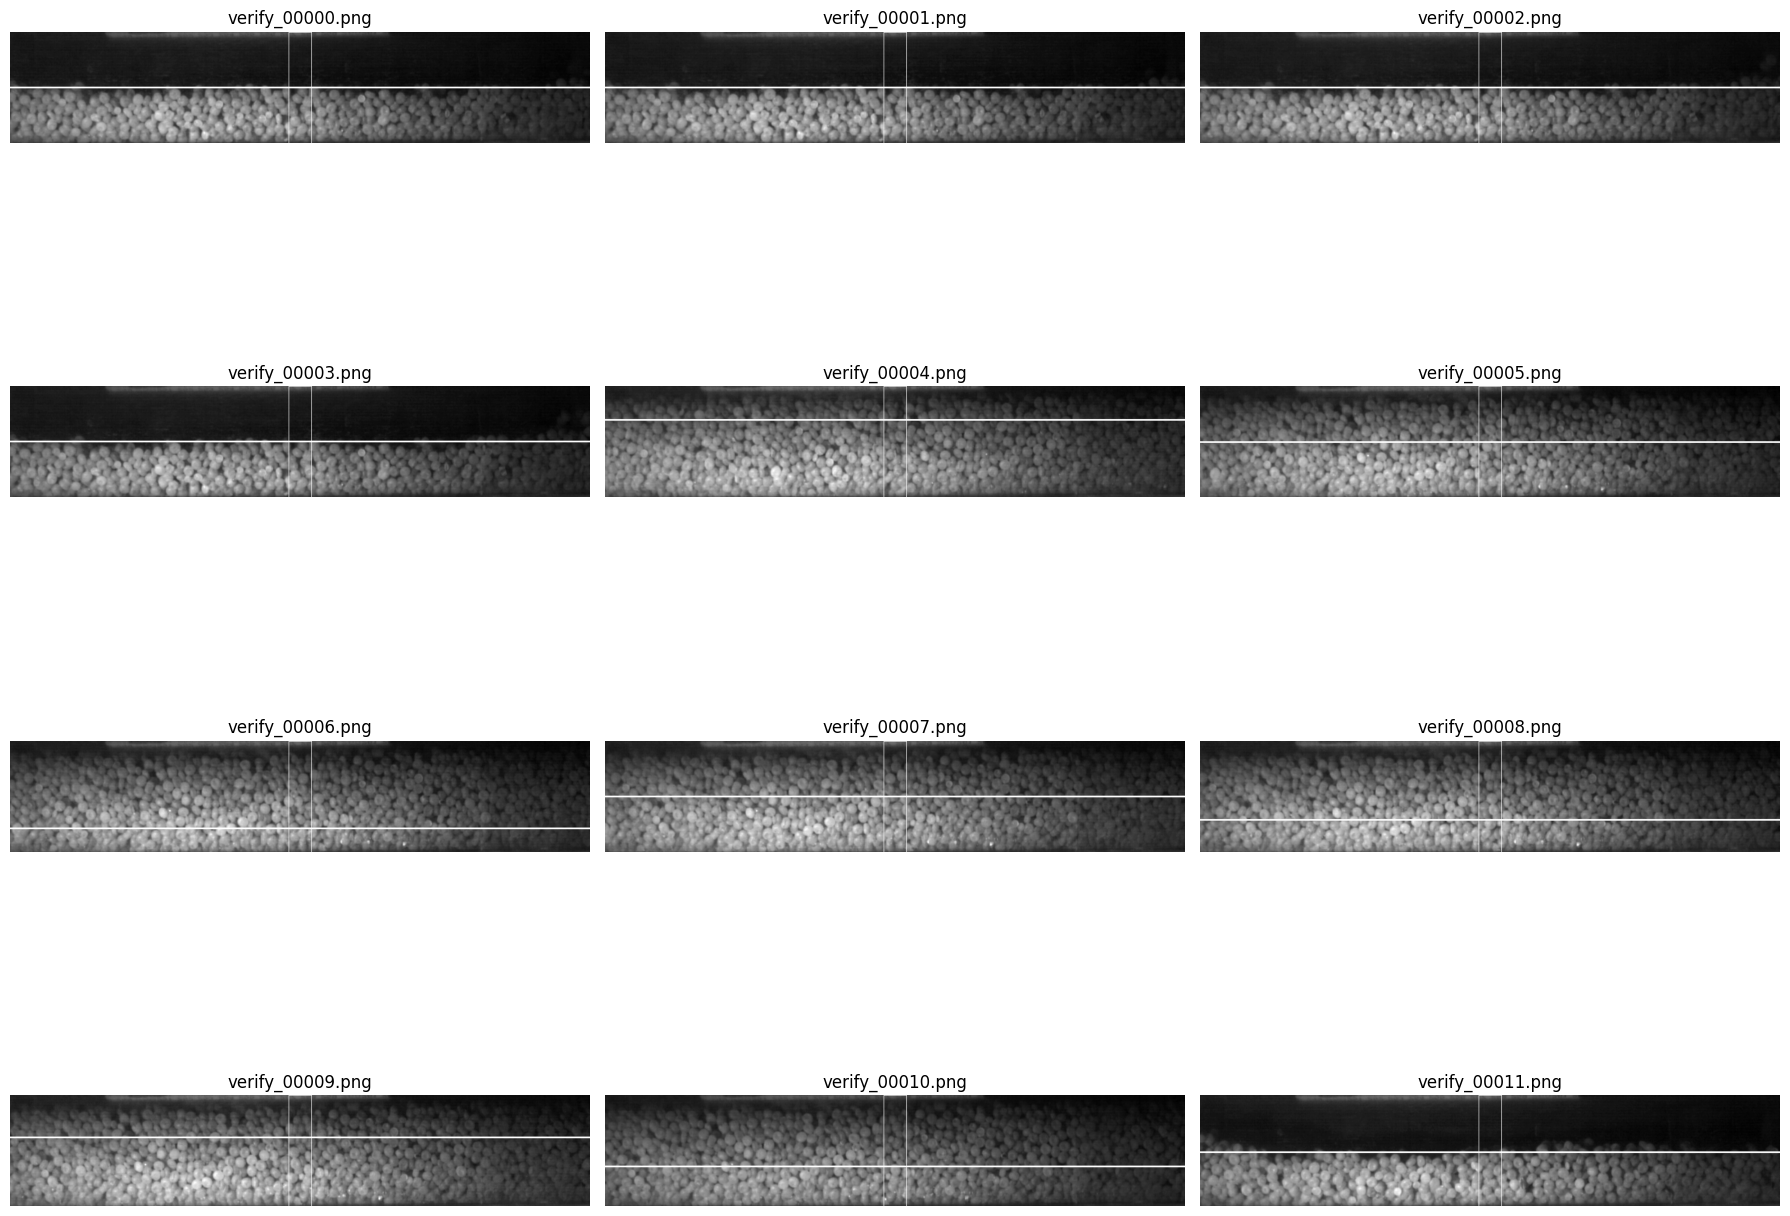

In [34]:
import cv2
import matplotlib.pyplot as plt
import os
from glob import glob
import math

VERIFY_FOLDER = "height_verification"

verify_files = sorted(
    glob(
        os.path.join(
            VERIFY_FOLDER,
            "*.png"
        )
    )
)

print(
    f"Found {len(verify_files)} verification images"
)

start = 0

num_show = min(
    12,
    len(verify_files) - start
)

selected = verify_files[
    start :
    start + num_show
]

cols = 3

rows = math.ceil(
    len(selected) / cols
)

fig, ax = plt.subplots(
    rows,
    cols,
    figsize=(18, 4 * rows)
)

ax = np.array(ax).reshape(-1)

for i, file in enumerate(selected):

    img = cv2.imread(file)

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    ax[i].imshow(img)

    ax[i].set_title(
        os.path.basename(file)
    )

    ax[i].axis("off")

for j in range(
    len(selected),
    len(ax)
):

    ax[j].axis("off")

plt.tight_layout()

plt.show()

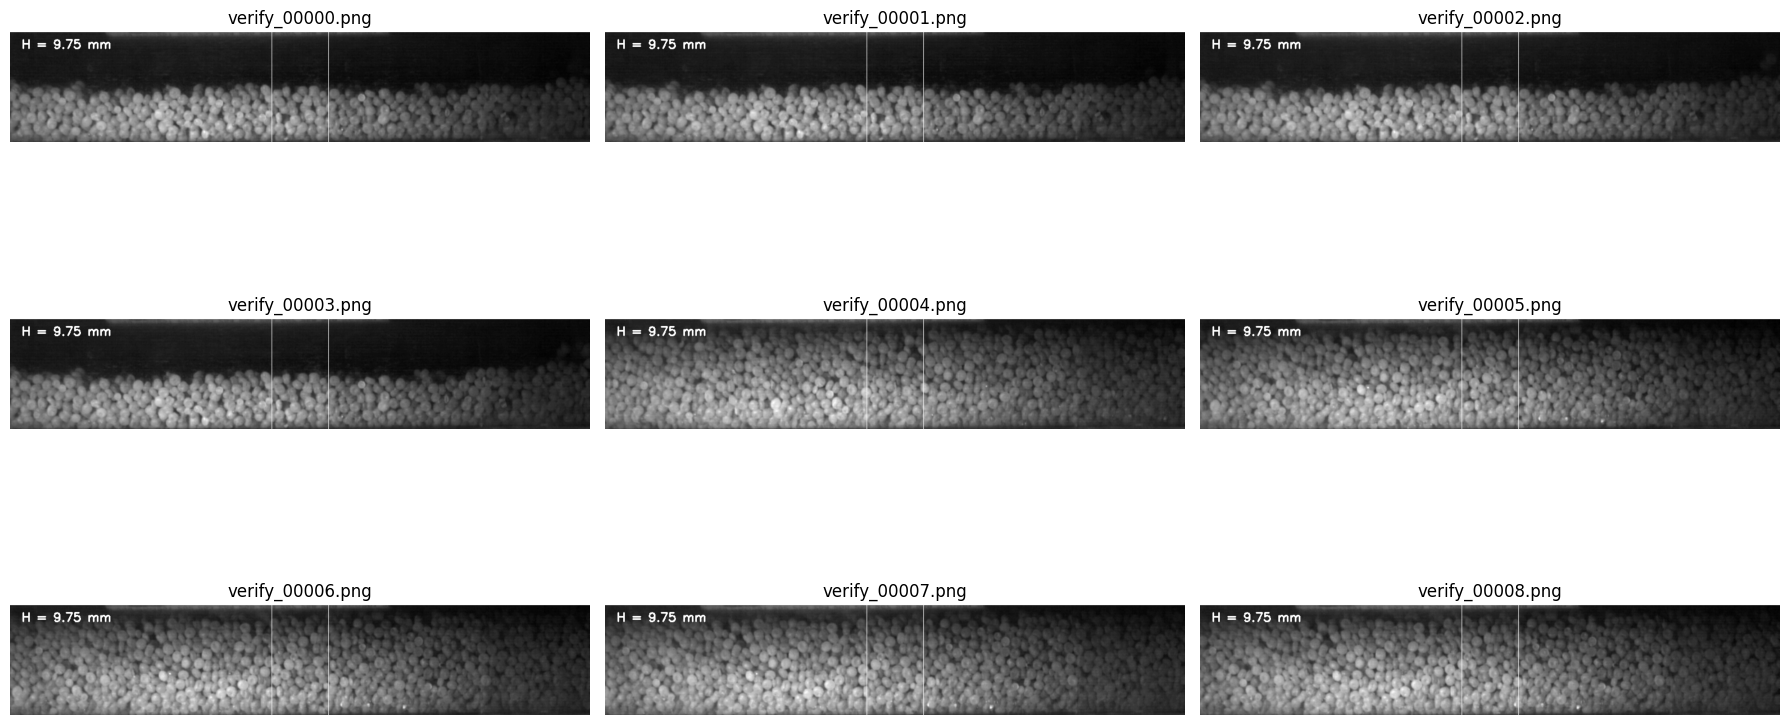

In [29]:
import cv2
import matplotlib.pyplot as plt
import os
from glob import glob

VERIFY_FOLDER = "height_verification"

verify_files = sorted(
    glob(
        os.path.join(
            VERIFY_FOLDER,
            "*.png"
        )
    )
)

N = min(9, len(verify_files))

fig, ax = plt.subplots(
    3,
    3,
    figsize=(18,10)
)

ax = ax.flatten()

for i in range(N):

    img = cv2.imread(
        verify_files[i]
    )

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    ax[i].imshow(img)

    ax[i].set_title(
        os.path.basename(
            verify_files[i]
        )
    )

    ax[i].axis("off")

for i in range(N, 9):

    ax[i].axis("off")

plt.tight_layout()

plt.show()